# EfficientNet-B4 — Feature Extraction (Photo → Tensor)

This notebook takes the trained EfficientNet-B4 spatial model and uses it as a **feature extractor**.
The classifier head is removed, so instead of predicting a class, the model outputs a **1792-dimensional embedding** for each frame.

For each 16-frame sequence in the temporal dataset, we get a tensor of shape `(16, 1792)` — one vector per frame.
These tensors are saved as `.npy` files and will be used as input for the LSTM classifier in the next stage.

## 1. Imports & Setup

In [1]:
import os
import shutil
import zipfile
import random
import numpy as np
import torch
import timm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from google.colab import drive

!pip install ipython-autotime -q
%load_ext autotime

device = torch.device('cuda')
print(f'Using device: {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.6 MB/s eta 0:00:00
Using device: cuda
time: 572 µs (started: 2026-04-08 17:21:48 +00:00)


## 2. Mount Drive & Configure Paths

In [2]:
drive.mount('/content/drive')

BASE        = '/content/drive/MyDrive/DriveGuard'
weights_src = f'{BASE}/models/efficientnet_b4_spatial_model_v1.pth'
zip_src     = f'{BASE}/all_cams_ds_driveguard_temporal_roi.zip'

# local paths — faster I/O than reading directly from Drive
weights_dst = '/content/effnet_b4_weights.pth'
zip_dst     = '/content/temporal_roi.zip'
data_dir    = '/content/ds_driveguard_temporal_roi'
out_dir     = f'{BASE}/CNN_Features'

print(f'Weights : {weights_src}')
print(f'Dataset : {zip_src}')
print(f'Output  : {out_dir}')

Mounted at /content/drive
Weights : /content/drive/MyDrive/DriveGuard/models/efficientnet_b4_spatial_model_v1.pth
Dataset : /content/drive/MyDrive/DriveGuard/all_cams_ds_driveguard_temporal_roi.zip
Output  : /content/drive/MyDrive/DriveGuard/CNN_Features
time: 55.9 s (started: 2026-04-08 17:21:48 +00:00)


## 3. Copy Files to Local Storage

Copying weights and dataset zip to `/content` speeds up loading — reading large files directly from Drive is significantly slower.

In [3]:
if not os.path.exists(weights_dst):
    print('Copying weights...')
    shutil.copy(weights_src, weights_dst)
else:
    print('Weights already cached locally.')

if not os.path.exists(zip_dst):
    print('Copying dataset zip...')
    shutil.copy(zip_src, zip_dst)
else:
    print('Dataset zip already cached locally.')

Copying weights...
Copying dataset zip...
time: 12min 21s (started: 2026-04-08 17:22:44 +00:00)


## 4. Extract Dataset

In [4]:
if not os.path.exists(data_dir):
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_dst) as z:
        z.extractall('/content/')
    print('Done.')
else:
    print('Dataset already extracted.')

os.makedirs(out_dir, exist_ok=True)

Extracting dataset...
Done.
time: 4min 16s (started: 2026-04-08 17:35:05 +00:00)


## 5. Dataset & Preprocessing

`ClipDataset` walks the `train/val/test` splits and collects all 16-frame sequences.
Each sequence folder contains `frame_00.jpg` through `frame_15.jpg`.

Preprocessing matches exactly what was used during EfficientNet-B4 training:
- Resize to **380×380** (native EfficientNet-B4 resolution)
- ImageNet normalization (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`)

In [5]:
class ClipDataset(Dataset):
    def __init__(self, root, transform):
        self.transform = transform
        self.clips = []
        for split in ('train', 'val', 'test'):
            for label in ('Drink', 'Phone', 'Safe'):
                folder = os.path.join(root, split, label)
                if not os.path.isdir(folder):
                    continue
                for seq in os.listdir(folder):
                    seq_path = os.path.join(folder, seq)
                    if os.path.isdir(seq_path):
                        self.clips.append((seq_path, split, label, seq))

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        path, split, label, name = self.clips[idx]
        jpgs   = sorted(f for f in os.listdir(path) if f.endswith('.jpg'))[:16]
        frames = [self.transform(Image.open(os.path.join(path, f)).convert('RGB')) for f in jpgs]
        return torch.stack(frames), split, label, name

time: 1.39 ms (started: 2026-04-08 17:39:21 +00:00)


In [6]:
tfm = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = ClipDataset(data_dir, tfm)
loader  = DataLoader(dataset, batch_size=4, num_workers=4, pin_memory=True)

print(f'Total sequences: {len(dataset)}')

Total sequences: 17019
time: 96.2 ms (started: 2026-04-08 17:39:21 +00:00)


## 6. Load Model

Load the trained EfficientNet-B4 and call `reset_classifier(0)` to remove the final linear layer.
After this, the model outputs raw **1792-dim** embeddings (the output of the global average pooling layer).

`torch.compile` is used when available for faster inference.

In [7]:
net = timm.create_model('efficientnet_b4', pretrained=False, num_classes=3)
net.load_state_dict(torch.load(weights_dst, map_location=device))
net.reset_classifier(0)
net = net.to(device).to(torch.bfloat16).eval()

try:
    net = torch.compile(net)
    print('Model compiled with torch.compile')
except Exception:
    print('torch.compile not available — running in eager mode')

# quick output-shape check
with torch.no_grad():
    dummy = torch.zeros(1, 3, 380, 380).to(device, dtype=torch.bfloat16)
    out   = net(dummy)
    print(f'Feature dim: {out.shape[1]}')

Model compiled with torch.compile
Feature dim: 1792
time: 41.9 s (started: 2026-04-08 17:39:21 +00:00)


## 7. Extract & Save Features

For each batch of sequences:
1. Reshape `(B, 16, C, H, W)` → `(B×16, C, H, W)` to run all frames through the model in one forward pass
2. Reshape output back to `(B, 16, 1792)`
3. Save each sequence as `{seq_name}.npy` under `CNN_Features/{split}/{class}/`

Already-extracted files are skipped so the cell is safe to re-run.

In [8]:
skipped = 0

with torch.no_grad():
    for clips, splits, labels, names in tqdm(loader, desc='Extracting features'):
        B, T, C, H, W = clips.shape
        flat = clips.view(B * T, C, H, W).to(device, dtype=torch.bfloat16)

        with torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16):
            feats = net(flat)                              # (B*T, 1792)

        feats = feats.view(B, T, -1).cpu().float().numpy()  # (B, 16, 1792)

        for i in range(B):
            save_dir  = os.path.join(out_dir, splits[i], labels[i])
            os.makedirs(save_dir, exist_ok=True)
            save_path = os.path.join(save_dir, f'{names[i]}.npy')
            if os.path.exists(save_path):
                skipped += 1
                continue
            np.save(save_path, feats[i])

print(f'Extraction complete. Skipped (already saved): {skipped}')

Extracting features:   0%|          | 0/4255 [00:00<?, ?it/s]

Extraction complete. Skipped (already saved): 0
time: 19min 23s (started: 2026-04-08 17:40:03 +00:00)


## 8. Verification

Count the saved files and inspect a random sample to confirm shape and values look correct.
Expected shape: `(16, 1792)`. No NaNs should be present.

In [9]:
npy_files = [
    os.path.join(r, f)
    for r, _, fs in os.walk(out_dir)
    for f in fs if f.endswith('.npy')
]
print(f'Total .npy files saved: {len(npy_files)}')

# per-split breakdown
for split in ('train', 'val', 'test'):
    count = sum(1 for p in npy_files if f'/{split}/' in p)
    print(f'  {split}: {count}')

Total .npy files saved: 17019
  train: 10259
  val: 2713
  test: 4047
time: 299 ms (started: 2026-04-08 17:59:27 +00:00)


File  : a_column_co_driver_vp8_run2_2018-05-23-15-30-27.ids_2_ann16_ch6.npy
Shape : (16, 1792)
Dtype : float32
NaNs  : False
Min   : -0.2139  Max: 0.3340


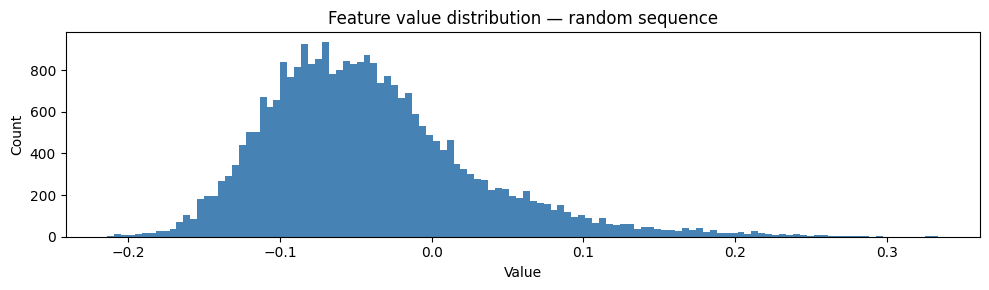

time: 301 ms (started: 2026-04-08 17:59:27 +00:00)


In [10]:
sample_path = random.choice(npy_files)
sample      = np.load(sample_path)

print(f'File  : {os.path.basename(sample_path)}')
print(f'Shape : {sample.shape}')      # (16, 1792)
print(f'Dtype : {sample.dtype}')
print(f'NaNs  : {np.isnan(sample).any()}')
print(f'Min   : {sample.min():.4f}  Max: {sample.max():.4f}')

plt.figure(figsize=(10, 3))
plt.hist(sample.flatten(), bins=120, color='steelblue', edgecolor='none')
plt.title('Feature value distribution — random sequence')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()